In [1]:
import sys
sys.path.insert(0, '..')

import numpy  as np
import tensorflow as tf
import math
import pandas as pd

from model.data import getDataETTh1,Normalize
from model.model import myInformer
from model.exp import Exp

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

OUT (32, 24, 7)
(32, 24, 7)
(32, 96, 7)
start: 11848


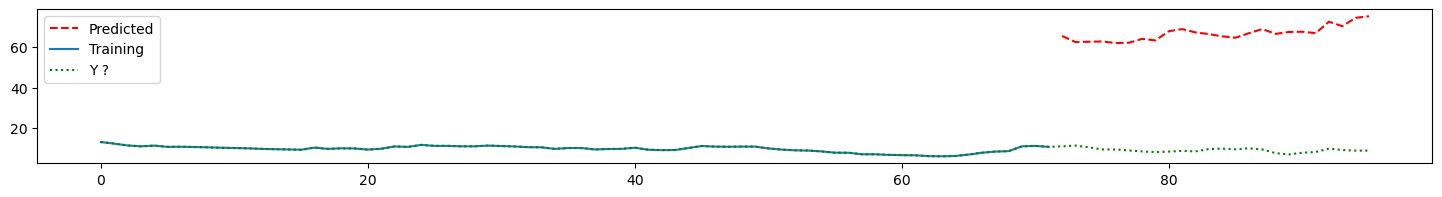

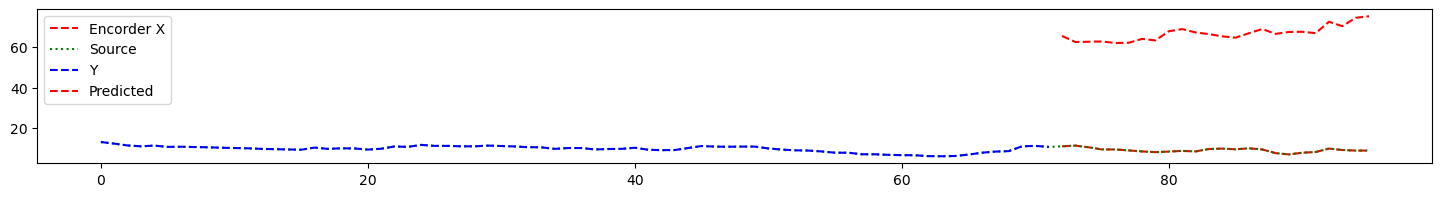

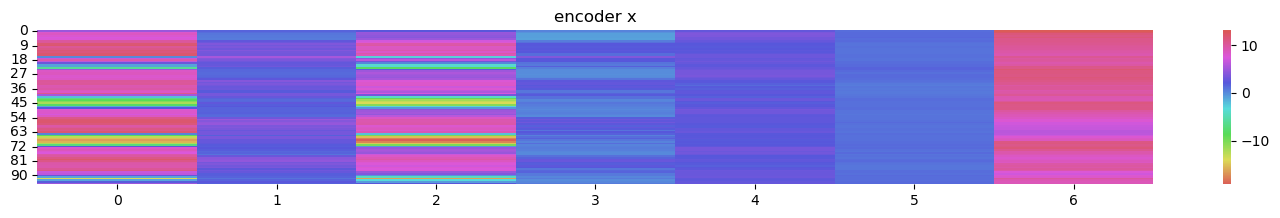

In [5]:
# EXP
d_model = 512
HEADS = 8
RATE = 0.05
SEQ_LEN = 96
FACTOR = 5
BATCH_SIZE = 32
GLOBAL_SIZE = 0
d_ff= 2048
TIME_FEATURES = 4
N=2

PRED_LEN =24

FEATURES= 7

settings = {'batch_size':BATCH_SIZE, 'seq_len':SEQ_LEN, 'global_size':GLOBAL_SIZE, 'd_model':d_model, 'd_ff':d_ff,
            'e_layer':N, 'd_layer':1, 'rate':RATE, 'factor':FACTOR, 'heads':HEADS, 'pred_len':PRED_LEN, 'features':FEATURES, 'timeFeatures':TIME_FEATURES }
# print(settings)

myExpFct = Exp(settings)
myExpFct._build()
pred = myExpFct.pred(myExpFct.x_enc,myExpFct.x_dec,myExpFct.X_date_enc, myExpFct.X_date_dec, training=False)
# pred = myExpFct._pred()

B,L,F = pred.shape
print(pred.shape)
pred = myExpFct.scalerX.inverse_transform(tf.reshape(pred,shape=(B*L,F)))
pred = tf.cast(tf.reshape(pred, shape=(B,L,F)), tf.float32)
x_padd = tf.zeros(shape=(BATCH_SIZE,72,7))
pred = tf.concat([x_padd,pred],1)
print(pred.shape)

x_ = myExpFct.x_enc

B,L,F = x_.shape
x_ = tf.reshape(x_, shape=(B*L,F))
x_ = myExpFct.scalerX.inverse_transform(x_)
x_ = tf.reshape(x_, shape=(B,L,F))

start = int(myExpFct.start)
print('start:', start)

v_min = tf.reduce_min(x_)
v_max = tf.reduce_max(x_)

fig = plt.figure(figsize=(18,2))
plt.plot(range(pred[0,0:SEQ_LEN-PRED_LEN,6].shape[0], SEQ_LEN),pred[0,SEQ_LEN-PRED_LEN:SEQ_LEN,6], 'r--', label="Predicted");
plt.plot(range(x_[0,0:SEQ_LEN-PRED_LEN,6].shape[0]),x_[0,0:SEQ_LEN-PRED_LEN,6], label="Training");
plt.plot(range(0, SEQ_LEN),myExpFct.Yt[start-SEQ_LEN:start,6], 'g:', label="Y ?");
plt.legend();

OFFSET = 100
fig = plt.figure(figsize=(18,2))
plt.plot(range(72, SEQ_LEN),x_[0,72:SEQ_LEN,6], 'r--', label="Encorder X");
plt.plot(range(0, SEQ_LEN),myExpFct.X[start:start+SEQ_LEN,0,6], 'g:', label="Source");
plt.plot(range(0, SEQ_LEN-24),myExpFct.Yt[start-SEQ_LEN:start-24,6], 'b--', label="Y");
plt.plot(range(pred[0,0:SEQ_LEN-PRED_LEN,6].shape[0], SEQ_LEN),pred[0,SEQ_LEN-PRED_LEN:SEQ_LEN,6], 'r--', label="Predicted");
plt.legend();

for i in range(0,BATCH_SIZE,32):
    fig = plt.figure(figsize=(18,2))
    sns.heatmap(x_[i,:,:], vmin=v_min, vmax=v_max, cmap=sns.color_palette("hls", 256)).set_title('encoder x');# for i in range(0,BATCH_SIZE,8):


In [ ]:
myDataFct = getDataETTh1(96)
dataSet, datsetVal = myDataFct.buildDataset(0.2)
dataSet

In [ ]:
# Model
d_model = 512
HEADS = 8
RATE = 0.05
SEQ_LEN = 96
FACTOR = 5
BATCH_SIZE = 32
GLOBAL_SIZE = 1000
N = 2
d_ff= 2048

PRED_LEN =24

tf.keras.backend.clear_session()

myModelFct = myInformer(
    seq_len=SEQ_LEN, pred_len=PRED_LEN,batch_size=BATCH_SIZE,d_model=d_model,rate=RATE,factor=FACTOR,head=HEADS,d_ff=d_ff,
    e_layer=N,features=7
)

# Get DATA
dataFct = getDataETTh1(SEQ_LEN,GLOBAL_SIZE)
x, x_date, Yt, YtDate, df_raw = dataFct.get()

#format DATA
L, S, F = x.shape
_, _, Fd = x_date.shape
x,scaler = Normalize(tf.reshape(x, [L,-1]))
x = tf.reshape(x,[L,S,F])
x = tf.cast(x,tf.float32)
x_date,scaler = Normalize(tf.reshape(x_date,[L,-1]))
x_date = tf.reshape(x_date,[L,S,Fd])
x_date = tf.cast(x_date,tf.float32)

start = np.random.randint(0,GLOBAL_SIZE-BATCH_SIZE)

dec_len = self.seq_len // 2
x_enc, x_date_enc = [ x[start:start+self.batch_size,:self.seq_len,:] , x_date[start:start+self.batch_size,:self.seq_len,:]]
x_dec, x_date_dec = [ x[start:start+self.batch_size,:dec_len,:] , x_date[start:start+self.batch_size,:dec_len,:]]
x_dec_padd = tf.zeros(shape=(self.batch_size,self.pred_len,x.shape[-1]))
x_date_dec_padd = tf.zeros(shape=(self.batch_size,self.pred_len,x_date.shape[-1]))
x_dec = tf.concat([x_dec,x_dec_padd],1)
x_date_dec = tf.concat([x_date_dec,x_date_dec_padd],1)


pred, outDec, outEnc, decEmb, encEmb, attn, xN, x_dateN, x_enc = myModelFct(x,x_date,start)

outInf = pred[:,-24:,:]
print('prediction',outInf.shape)
print(outInf[0,:,-1].shape)
# print(x_enc[0,-48:-24,-1].shape)
# df = pd.DataFrame(np.vstack((outInf[0,:,-1],x_enc[0,-48:-24,-1]))) #,columns=['Pred','Vrai'])
Xt_min = tf.reduce_min(x)
Xt_max = tf.reduce_max(x)
Out_min = tf.reduce_min(pred)
Out_max = tf.reduce_max(pred)
# fig = plt.figure(figsize=(18,2))
# sns.lineplot(x=df_raw['date'][:GLOBAL_SIZE],y=df_raw['OT'][:GLOBAL_SIZE]).set_title('Data Brutes [0-32]');
# fig = plt.figure(figsize=(18,2))
# sns.lineplot(outInf[0,:,-1]).set_title('Prédictions');
fig = plt.figure(figsize=(4,2))
sns.heatmap(attn[0][0,0,:,:], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Attention');
fig = plt.figure(figsize=(18,2))
sns.heatmap(x[0,:,:], vmin=Xt_min, vmax=Xt_max, cmap=sns.color_palette("hls", 256)).set_title('Init Features Data');
for i in range(0,BATCH_SIZE,32):
    fig = plt.figure(figsize=(18,2))
    sns.heatmap(encEmb[i,:,:], vmin=-10, vmax=10, cmap=sns.color_palette("hls", 256)).set_title('Enc Embedding');
for i in range(0,BATCH_SIZE,32):
    fig = plt.figure(figsize=(18,2))
    sns.heatmap(decEmb[i,:,:], vmin=-10, vmax=10, cmap=sns.color_palette("hls", 256)).set_title('Dec Embedding');
for i in range(0,BATCH_SIZE,32):
    fig = plt.figure(figsize=(18,2))
    sns.heatmap(outEnc[i,:,:], vmin=Out_min, vmax=Out_max, cmap=sns.color_palette("hls", 256)).set_title('Encoder');# for i in range(0,BATCH_SIZE,8):
for i in range(0,BATCH_SIZE,32):
    fig = plt.figure(figsize=(18,2))
    sns.heatmap(outDec[i,:,:], vmin=Out_min, vmax=Out_max, cmap=sns.color_palette("hls", 256)).set_title('Decoder');# for i in range(0,BATCH_SIZE,8):

DATA_SIZE = SEQ_LEN
LOOP = SEQ_LEN
FORCAST = PRED_LEN
x_padd = tf.zeros(shape=(BATCH_SIZE,24,7))
x_pred = tf.concat([x_padd,pred],1)

# print(xN.shape, pred.shape, x_pred.shape)
# print('-----')
# print(range(xN[start,DATA_SIZE-LOOP:DATA_SIZE-FORCAST,6].shape[0]),xN[0,DATA_SIZE-LOOP:DATA_SIZE-FORCAST,6])
# print(range(xN[0,DATA_SIZE-LOOP:DATA_SIZE-FORCAST,6].shape[0], LOOP),xN[0,DATA_SIZE-FORCAST:DATA_SIZE,6])
# print(range(pred[0,0:48,6].shape[0], 72),pred[0,48:72,6])
# print()
fig = plt.figure(figsize=(18,3))
plt.plot(range(x_enc[0,DATA_SIZE-LOOP:DATA_SIZE-FORCAST,6].shape[0]),x_enc[0,DATA_SIZE-LOOP:DATA_SIZE-FORCAST,6], label="Training");
plt.plot(range(x_pred[0,0:72,6].shape[0], 96),x_pred[0,72:96,6], 'r--', label="Predicted");
# plt.plot(range(xN[0,DATA_SIZE-LOOP:DATA_SIZE-FORCAST,6].shape[0], LOOP),xN[0,DATA_SIZE-FORCAST:DATA_SIZE,6], 'r--', label="Predicted");
plt.plot(range(x_enc[0,DATA_SIZE-LOOP:DATA_SIZE-FORCAST,6].shape[0], LOOP),x_enc[0,DATA_SIZE-FORCAST:DATA_SIZE,6], 'g--', label="Réel");
plt.legend();
